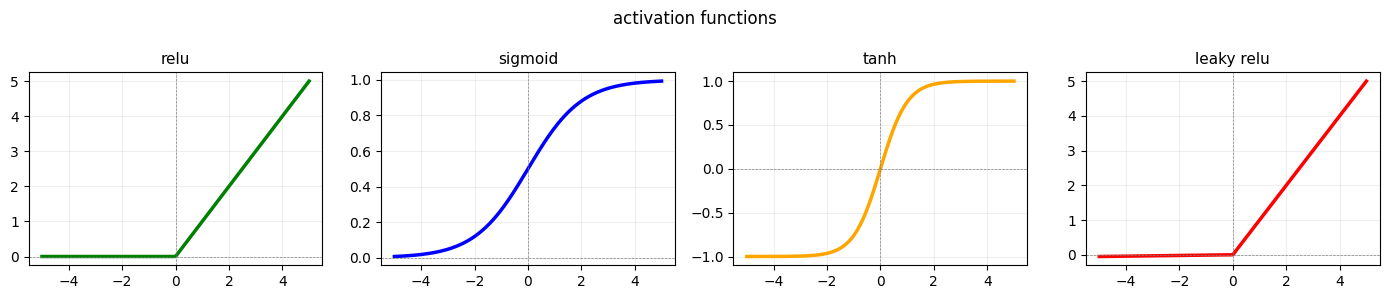

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
x=np.linspace(-5,5,300)
relu=lambda x:np.maximum(0,x)
sigmoid=lambda x:1/(1+np.exp(-x))
tanh_fn=np.tanh
leaky=lambda x:np.where(x>0,x,0.01*x)
fig, axes = plt.subplots(1,4,figsize=(14,3))
fns=[relu,sigmoid,tanh_fn,leaky]
names=['relu','sigmoid','tanh','leaky relu']
cols=['green','blue','orange','red']
for ax,fn,name,col in zip(axes,fns,names,cols):
  ax.plot(x,fn(x),color=col,linewidth=2.5)
  ax.axhline(0,color='gray',lw=0.5,ls='--')
  ax.axvline(0,color='gray',lw=0.5,ls='--')
  ax.set_title(name,fontsize=11)
  ax.grid(alpha=0.2)
plt.suptitle('activation functions',fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
(x_train,y_train),(x_test,y_test)=keras.datasets.mnist.load_data()
x_train=x_train.reshape(-1,784)
x_test=x_test.reshape(-1,784)
x_train=x_train.astype('float32')/255.0
x_test=x_test.astype('float32')/255.0
print(f'train:{x_train.shape} test:{x_test.shape}')
model=keras.Sequential([
keras.Input(shape=(784,)),
layers.Dense(128,activation='relu'),

layers.Dropout(0.2),
layers.Dense(64,activation='relu'),
layers.Dropout(0.2),
layers.Dense(10,activation='softmax')
])
model.summary()

train:(60000, 784) test:(10000, 784)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
optimizer='Adam',
loss='sparse_categorical_crossentropy',
metrics=["accuracy"],
)

from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)

reduce_lr = ReduceLROnPlateau(monitor='val_loss', patience=3, factor=0.5, min_lr=1e-6, verbose=1)

history = model.fit(x_train, y_train, batch_size=128, epochs=50, validation_split=0.1, callbacks=[early_stop, reduce_lr], verbose=1)

Epoch 1/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.8568 - loss: 0.4796 - val_accuracy: 0.9572 - val_loss: 0.1491 - learning_rate: 0.0010
Epoch 2/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9387 - loss: 0.2076 - val_accuracy: 0.9702 - val_loss: 0.1005 - learning_rate: 0.0010
Epoch 3/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9527 - loss: 0.1575 - val_accuracy: 0.9728 - val_loss: 0.0888 - learning_rate: 0.0010
Epoch 4/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9613 - loss: 0.1282 - val_accuracy: 0.9758 - val_loss: 0.0795 - learning_rate: 0.0010
Epoch 5/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9658 - loss: 0.1099 - val_accuracy: 0.9777 - val_loss: 0.0725 - learning_rate: 0.0010
Epoch 6/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9698 - loss: 0.0974 - val_accuracy: 0.9790 - val_loss: 0.0714 - learning_rate: 0.0010
Epoch 7/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9730 - loss: 0.0878 - 

Test Accuracy: 98.11%
Test Loss: 0.0678


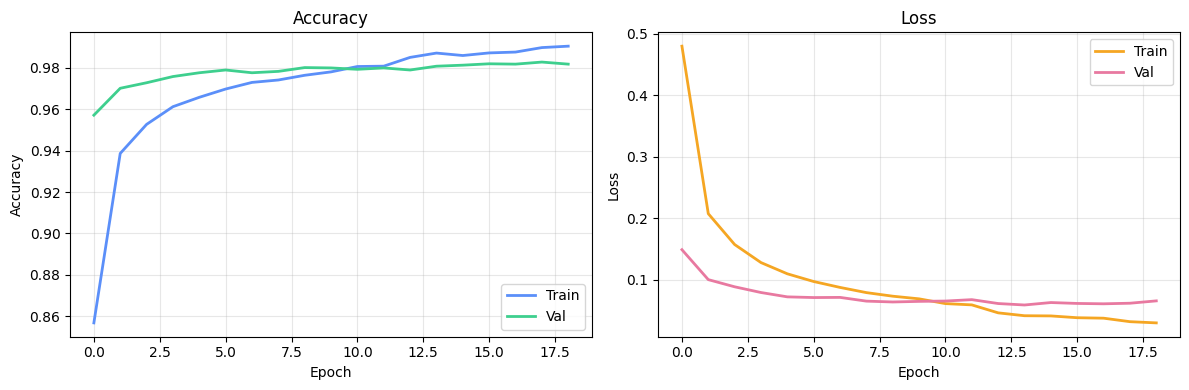

In [ ]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f'Test Accuracy: {test_acc*100:.2f}%') # expect 97-98%
print(f'Test Loss: {test_loss:.4f}')
import matplotlib.pyplot as plt
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history.history['accuracy'], label='Train', color='#5B8FF9', lw=2)
ax1.plot(history.history['val_accuracy'], label='Val', color='#3ECF8E', lw=2)
ax1.set(title='Accuracy', xlabel='Epoch', ylabel='Accuracy')
ax1.legend(); ax1.grid(alpha=0.3)
ax2.plot(history.history['loss'], label='Train', color='#F5A623', lw=2)
ax2.plot(history.history['val_loss'], label='Val', color='#E879A0', lw=2)
ax2.set(title='Loss', xlabel='Epoch', ylabel='Loss')
ax2.legend(); ax2.grid(alpha=0.3)
plt.tight_layout(); plt.show()